In [73]:
import cupy as cp
import math
import random
import matplotlib.pyplot as plt
from model.network import Network

## Loading the Data

In [74]:
training_path = "input/training.txt"
validation_path = "input/validation.txt"

with open(training_path, "r", encoding="utf-8") as file:
    training_data = file.read()

with open(validation_path, "r", encoding="utf-8") as file:
    validation_data = file.read()

training_data = list(training_data)
validation_data = list(validation_data)

x_train = training_data[:-1]
y_train = training_data[1:]

x_test = validation_data[:-1]
y_test = validation_data[1:]

print(f"Training data length: X={len(x_train)}, Y={len(y_train)}")
print(f"Validation data length: X={len(x_test)}, Y={len(y_test)}")

Training data length: X=880791, Y=880791
Validation data length: X=234596, Y=234596


In [75]:
vocabulary = sorted(set(training_data).union(set(validation_data)))
print(f"Vocabulary size: {len(vocabulary)}")

Vocabulary size: 65


In [76]:
def char_to_index(char: str) -> int:
    return vocabulary.index(char)

def index_to_char(index: int) -> str:
    return vocabulary[index]

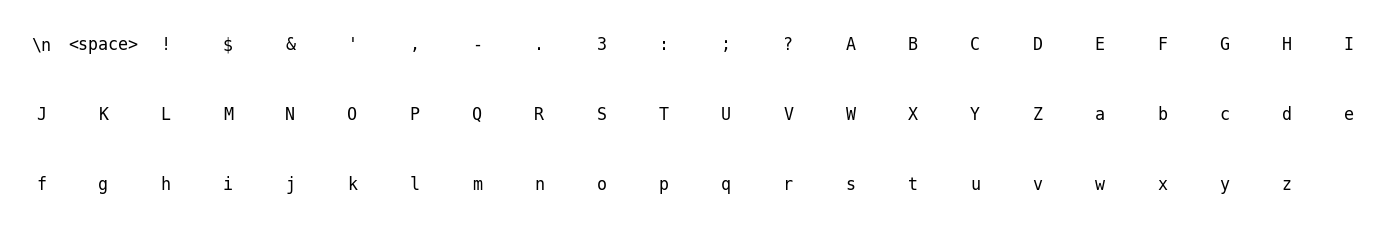

In [77]:
cols = 22
rows = math.ceil(len(vocabulary) / cols)

fig, ax = plt.subplots(figsize=(14, max(2, rows * 0.8)))

for index, token in enumerate(vocabulary):
    row, col = divmod(index, cols)
    display_token = {" ": "<space>", "\n": "\\n", "\t": "\\t"}.get(token, token)
    y = rows - row - 1
    ax.text(col, y, display_token, ha="center", va="center", fontsize=12, family="monospace")

ax.set_xlim(-0.5, cols - 0.5)
ax.set_ylim(-0.5, rows - 0.5)
ax.set_xticks(range(cols))
ax.set_yticks(range(rows))
ax.grid(True, linestyle=":", alpha=0.3)
plt.axis("off")
plt.tight_layout()
plt.show()

In [78]:
x_train_indices = cp.asarray([char_to_index(char) for char in x_train], dtype=cp.int32)
y_train_indices = cp.asarray([char_to_index(char) for char in y_train], dtype=cp.int32)
x_test_indices = cp.asarray([char_to_index(char) for char in x_test], dtype=cp.int32)
y_test_indices = cp.asarray([char_to_index(char) for char in y_test], dtype=cp.int32)

## Building the Model

In [79]:
embedding_dim = 128
hidden_size = 512
hidden_2_size = 256

layer_definitions = [
    {"type": "Embedding", "num_embeddings": len(vocabulary), "embedding_dim": embedding_dim},
    {"type": "Recurrent", "input_size": embedding_dim, "num_neurons": hidden_size},
    {"type": "Dropout", "rate": 0.2},
    {"type": "Recurrent", "input_size": hidden_size, "num_neurons": hidden_2_size},
    {"type": "Dropout", "rate": 0.2},
    {"type": "Softmax", "input_size": hidden_2_size, "num_neurons": len(vocabulary)},
]

network = Network(layer_definitions=layer_definitions)
network.describe()

Network Architecture

Layer 1: EmbeddingLayer
  Embeddings Shape: (65, 128)
  Parameters: 8,320

Layer 2: RecurrentLayer
  Weights Shape: (128, 512) | State Weights Shape: (512, 512) | Biases Shape: (512,)
  Parameters: 328,192

Layer 3: DropoutLayer
  Rate: 0.2

Layer 4: RecurrentLayer
  Weights Shape: (512, 256) | State Weights Shape: (256, 256) | Biases Shape: (256,)
  Parameters: 196,864

Layer 5: DropoutLayer
  Rate: 0.2

Layer 6: SoftmaxLayer
  Weights Shape: (256, 65) | Biases Shape: (65,)
  Parameters: 16,705

Total Parameters: 550,081


## Training the Model

In [80]:
def one_hot(indices: cp.ndarray, num_classes: int) -> cp.ndarray:
    encoded = cp.zeros((indices.shape[0], num_classes), dtype=cp.float32)
    encoded[cp.arange(indices.shape[0]), indices] = 1.0
    return encoded

In [81]:
def reshape_streams(
    x_indices: cp.ndarray,
    y_indices: cp.ndarray,
    batch_size: int,
    max_columns: int | None = None,
 ) -> tuple[cp.ndarray, cp.ndarray]:
    usable_tokens = (x_indices.shape[0] // batch_size) * batch_size
    x = x_indices[:usable_tokens].reshape(batch_size, -1)
    y = y_indices[:usable_tokens].reshape(batch_size, -1)

    if max_columns is not None:
        x = x[:, :max_columns]
        y = y[:, :max_columns]

    return x, y

In [82]:
def evaluate(
    network: Network,
    x_indices: cp.ndarray,
    y_indices: cp.ndarray,
    batch_size: int,
    sequence_length: int,
    max_steps: int | None = None,
) -> float:
    x, y = reshape_streams(
        x_indices=x_indices,
        y_indices=y_indices,
        batch_size=batch_size,
        max_columns=max_steps,
    )

    network.reset_states(batch_size=batch_size, dtype=cp.float32)
    total_loss = 0.0
    total_steps = x.shape[1]

    for step in range(total_steps):
        y_prob = network.forward(x[:, step])[-1]
        y_true = one_hot(y[:, step], len(vocabulary))
        total_loss += float(network.cce_loss(y_prob, y_true).item())

        if (step + 1) % sequence_length == 0:
            network.reset_states(batch_size=batch_size, dtype=cp.float32)

    return math.exp(total_loss / total_steps)


In [83]:
def train_epoch(
    network: Network,
    x_indices: cp.ndarray,
    y_indices: cp.ndarray,
    batch_size: int,
    sequence_length: int,
    learning_rate: float,
    max_steps: int | None = None,
    weight_decay_lambda: float = 0.0,
    momentum: float = 0.0,
    clip_value: float | None = None,
) -> float:
    network.set_training(True)
    x, y = reshape_streams(
        x_indices=x_indices,
        y_indices=y_indices,
        batch_size=batch_size,
        max_columns=max_steps,
    )
    network.reset_states(batch_size=batch_size, dtype=cp.float32)
    total_loss = 0.0
    total_steps = x.shape[1]

    for chunk_start in range(0, total_steps, sequence_length):
        chunk_end = min(chunk_start + sequence_length, total_steps)
        output_errors = []

        for step in range(chunk_start, chunk_end):
            y_prob = network.forward(x[:, step])[-1]
            y_true = one_hot(y[:, step], len(vocabulary))
            total_loss += float(network.cce_loss(y_prob, y_true).item())
            output_errors.append(y_prob - y_true)

        network.backward_sequence(output_errors, batch_size, clip_value=clip_value)
        network.update_parameters(learning_rate, weight_decay_lambda, momentum)
        network.reset_states(batch_size=batch_size, dtype=cp.float32)

    network.set_training(False)
    return math.exp(total_loss / total_steps)


In [ ]:
hyperparameters = {
    "sequence_length": 64,
    "batch_size": 64,
    "epochs": 1000,
    "train_steps_per_epoch": 4096,
    "validation_steps": 1024,
    "base_learning_rate": 0.03,
    "min_learning_rate": 0.0003,
    "weight_decay_lambda": 1e-4,
    "momentum": 0.9,
    "early_stopping_patience": 25,
    "clip_value": 5.0,
}

print(hyperparameters)

{'sequence_length': 64, 'batch_size': 64, 'epochs': 1000, 'train_steps_per_epoch': 4096, 'validation_steps': 1024, 'base_learning_rate': 0.03, 'min_learning_rate': 0.0003, 'weight_decay_lambda': 0.0001, 'momentum': 0.9, 'early_stopping_patience': 25, 'clip_value': 5.0}


In [85]:
epoch_summaries = []

total_steps = hyperparameters["epochs"] * hyperparameters["train_steps_per_epoch"]
global_step = 0

best_model = None
best_perplexity = float("inf")
epochs_without_improvement = 0

slice_size = hyperparameters["batch_size"] * hyperparameters["train_steps_per_epoch"]
max_offset = int(x_train_indices.shape[0]) - slice_size

for epoch in range(1, hyperparameters["epochs"] + 1):
    learning_rate = hyperparameters["min_learning_rate"] + 0.5 * (hyperparameters["base_learning_rate"] - hyperparameters["min_learning_rate"]) * (1 + math.cos(math.pi * global_step / total_steps))

    offset = random.randint(0, max_offset)
    x_slice = x_train_indices[offset : offset + slice_size]
    y_slice = y_train_indices[offset : offset + slice_size]

    train_perplexity = train_epoch(
        network=network,
        x_indices=x_slice,
        y_indices=y_slice,
        batch_size=hyperparameters["batch_size"],
        sequence_length=hyperparameters["sequence_length"],
        learning_rate=learning_rate,
        weight_decay_lambda=hyperparameters["weight_decay_lambda"],
        momentum=hyperparameters["momentum"],
        clip_value=hyperparameters["clip_value"],
    )
    test_perplexity = evaluate(
        network=network,
        x_indices=x_test_indices,
        y_indices=y_test_indices,
        batch_size=hyperparameters["batch_size"],
        sequence_length=hyperparameters["sequence_length"],
        max_steps=hyperparameters["validation_steps"],
    )

    epoch_summary = {
        "epoch": epoch,
        "learning_rate": learning_rate,
        "train_perplexity": train_perplexity,
        "test_perplexity": test_perplexity,
        "regularization": train_perplexity / test_perplexity,
    }
    epoch_summaries.append(epoch_summary)

    if epoch % 10 == 0 or epoch == 1:
        print(epoch_summary)

    if test_perplexity < best_perplexity:
        best_perplexity = test_perplexity
        best_model = network.clone()
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    global_step += hyperparameters["train_steps_per_epoch"]

    if epochs_without_improvement >= hyperparameters["early_stopping_patience"]:
        print(f"Early stopping triggered after {epoch} epochs due to no improvement.")
        break

{'epoch': 1, 'learning_rate': 0.03, 'train_perplexity': 18.318906225904474, 'test_perplexity': 10.66636869089514, 'regularization': 1.7174454359093712}
{'epoch': 10, 'learning_rate': 0.029994064568606305, 'train_perplexity': 7.431203094233384, 'test_perplexity': 6.6188278842470005, 'regularization': 1.122737019936696}
{'epoch': 20, 'learning_rate': 0.029973553119381446, 'train_perplexity': 6.5905915574328615, 'test_perplexity': 5.911244440611261, 'regularization': 1.1149245516146091}
{'epoch': 30, 'learning_rate': 0.029938412612897005, 'train_perplexity': 6.187783686666934, 'test_perplexity': 5.595980049978039, 'regularization': 1.1057551369739456}
{'epoch': 40, 'learning_rate': 0.029888677728590333, 'train_perplexity': 5.9113952662844245, 'test_perplexity': 5.3807023455480785, 'regularization': 1.0986289310679738}
{'epoch': 50, 'learning_rate': 0.029824397548787667, 'train_perplexity': 5.728478848726531, 'test_perplexity': 5.239995037486234, 'regularization': 1.0932221896673084}
{'epo

In [86]:
print(f"Best validation perplexity: {best_perplexity:.4f} at epoch {epoch - hyperparameters['early_stopping_patience']}")

Best validation perplexity: 4.1424 at epoch 946


In [93]:
import pickle

with open("best_rnn_model.pkl", "wb") as file:
    pickle.dump({
        "model": best_model,
        "vocabulary": vocabulary,
        "epoch_summaries": epoch_summaries,
    }, file)

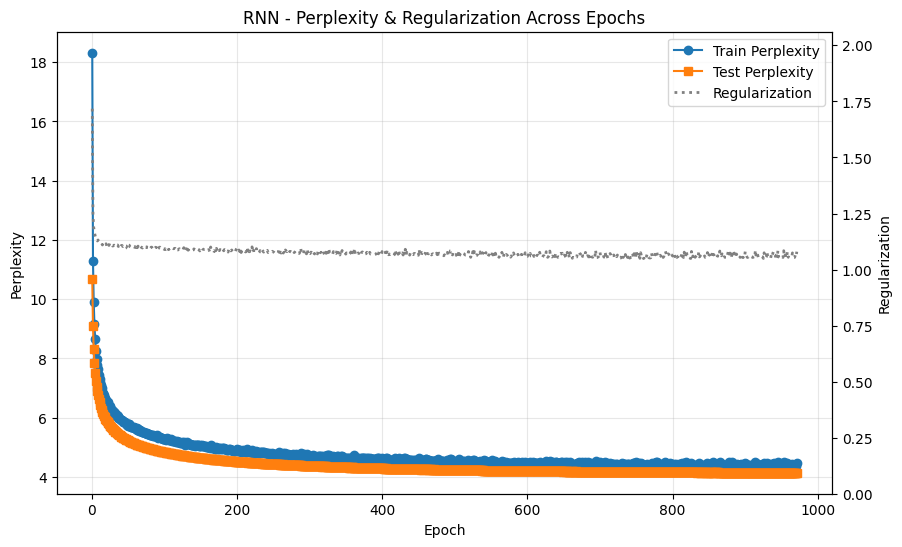

In [87]:
epochs_plot = [summary["epoch"] for summary in epoch_summaries]
train_perplexities = [summary["train_perplexity"] for summary in epoch_summaries]
test_perplexities = [summary["test_perplexity"] for summary in epoch_summaries]
regularizations = [summary["regularization"] for summary in epoch_summaries]

fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.plot(epochs_plot, train_perplexities, marker="o", label="Train Perplexity")
ax1.plot(epochs_plot, test_perplexities, marker="s", label="Test Perplexity")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Perplexity")
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(epochs_plot, regularizations, color="gray", linestyle=":", linewidth=2, label="Regularization")
ax2.set_ylim(0, max(regularizations) * 1.2)
ax2.set_ylabel("Regularization")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2)

plt.title("RNN - Perplexity & Regularization Across Epochs")
plt.show()

In [88]:
def generate_text(
    network: Network,
    seed_text: str,
    length: int = 250,
    temperature: float = 0.8,
    print_during: bool = True,
) -> str:
    network.reset_states(batch_size=1, dtype=cp.float32)
    generated = list(seed_text)

    if print_during:
        print(seed_text, end="")

    for character in seed_text:
        token_index = cp.asarray([char_to_index(character)], dtype=cp.int32)
        network.forward(token_index)

    current_character = seed_text[-1]

    for _ in range(length):
        token_index = cp.asarray([char_to_index(current_character)], dtype=cp.int32)
        y_prob = network.forward(token_index)[-1][0]
        log_prob = cp.log(y_prob + 1e-9) / temperature
        scaled_prob = cp.exp(log_prob - cp.max(log_prob))
        scaled_prob = scaled_prob / cp.sum(scaled_prob)
        next_index = int(
            cp.random.choice(len(vocabulary), size=1, p=scaled_prob)[0].item()
        )
        current_character = index_to_char(next_index)
        generated.append(current_character)

        if print_during:
            print(current_character, end="", flush=True)

    return "".join(generated)

In [89]:
seed_text = "DANIEL"
generated = generate_text(network=best_model, seed_text=seed_text, length=1000, temperature=0.85, print_during=True)

DANIEL:
Prove these dished heaving of his kinsficed for thee to the man, you are noble such a may
Are holy heart and the flower,
And the brother from our son, could shroh, that not my noble your wrongs
for his loving lands,
Unto meen in the more hence and death,
And see the father bring me, come to be conseitroos
That thee his head in good death, can put him man liege, it not catch my land,
And bear therefore good gone.

Second Murderer:
Affecture good to wife and the fearly mansman.
Cheer, the country's too much be age:
But I taken the dubsest it and your cousin pity;
And the power, if not sir, you shall stward stand, so worthy remave
To gave let thee, great to tresant some chamionees he does; on through for there to be leave;
For this blasts we for sufferly grudge conveying of life, he is strutity,
And fearful to me ercome, this no speck of the bade and subject
With my part in all resign,
Or hlawick?

NORTHUMBERLAND:
Yes, would not be judders repty and noble foul mean.

QUEEN:
Ay, se

In [90]:
seed_text = "DANIEL"
generated = generate_text(network=best_model, seed_text=seed_text, length=1000, temperature=0.8, print_during=True)

DANIEL:
First, my lord, this lady soul, but if our chide, and with thee to bearth in him.

ROMEO:
And therefore, my lord, sir.

CORIOLANUS:
All painting soul, which to the king.

PETRUCHIO:
Please the blood on a wits
More, hath befole her thus; he stands aguing thy heaven, sir, thou know not not, to propers
Of thy children, which for his words
Come upon the word,
Will be hope so proved up the poor ofich
Against my arms the haughter,
And not pass and such supplace;
Divise with your myself,
That was he raven is foot, do you, is counsel, be unto the clame and throne by these about this, not make his highonted.

CLARENCE:
You are hearth, but taken the recond with their sword upon his mmanded?

QUEEN MARCAM,
Consting a mother, that still be thy honour,
And let me in the hour onuth was with about and that's somement,
Master deserve upon
the fees? he must be in grain:
She so changes more to speak to me to live and all the best.
The instruments a makes me by the lord; I thought other best sees

In [91]:
seed_text = "DANIEL"
generated = generate_text(network=best_model, seed_text=seed_text, length=1000, temperature=0.75, print_during=True)

DANIEL:
My mintle were he done.

KING RICHARD II:
Are I most order marriage thou art sour strong.

PAULINA:
Some will person his mother dispotient of him;
For virtue and head of his remember.

Nurse:
And by the son, desires to him.

CLARENCE:
Ay, guilt power of thy metter daughter.

AUTOLYCUS:
Mare's sweet I hope of his pernect command.

CAPULET:
No more.

ESCALUS:
Why, the body which and in a king.

CLARENCE:
You false that what is that mean of him;
And we do so facred dear burister; perpressing like on his back to his heaven to some wearth.

First God where a will hear no romal.

CLARENCE:
Good service of both words; but sister and rich cannot to say.

KING EDWARD IV:
And spake the churchide the married at him wherefore as the hold
Would be not not we to the life?

LORD:
The man many name of men, and yet in the blood,
A fire shall scorn the comout at to most lamenter understands unto your countrymen:
Is you have one your mother's with the sake.
The father Hereford I have be dead?

ME

In [92]:
seed_text = "DANIEL"
generated = generate_text(network=best_model, seed_text=seed_text, length=1000, temperature=0.7, print_during=True)

DANIEL:
I shall for my overtise a wits of their brother was me;
And I not gods are the fire as we shall see the cause. That is the vices
Of the highness to what we'll proposed for the deforced so detite.

PRINCE:
Ay, is the less of the old pursue of the doubt, and that
That words of your weeps
That the rage, my lord.

KING RICHARD II:
The comfort that for the both be part
That she I think you with him.

MISTRENSSO:
Be in the oath, that have the king?

First Citizen:
Here is the seneral leave; and be offence and there!

Second Citizen:
Here is your news;
It is not am I have sentence of the crown.

BRUTUS:
Now it bath so justice stand in merry. The house of his wife
The peace?

QUEEN MARGARET:
Is there promise him to to dry the true breath.

ABBALINA:
What, be the tears!
I would not, go your woman that, Clarence, they have king person, and every weapules and earth.

POLIXENES:
What you have the since
The villain he did been dost thou have a strong.

First Citizen:
What is regoor stand to